In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HRM\Downloads\datacenter_power_data.csv")

df.head()

,timestamp,date,hour,month,day_of_week,is_weekday,it_load_kw,cooling_power_kw,overhead_power_kw,total_facility_power_kw,pue,outside_temp_c,server_inlet_temp_c,humidity_pct,water_usage_litres,is_anomaly,wue,dcie_pct
0,2024-01-01 00:00:00,2024-01-01,0,1,Monday,1,895.62,307.49,65.40,1268.52,1.4164,-1.05,18.94,47.97,256.21,0,0.2861,70.60
1,2024-01-01 01:00:00,2024-01-01,1,1,Monday,1,876.57,277.92,63.89,1218.39,1.3899,-5.41,19.77,45.81,185.30,0,0.2114,71.95
2,2024-01-01 02:00:00,2024-01-01,2,1,Monday,1,900.15,260.32,62.19,1222.66,1.3583,-4.70,18.09,42.34,203.79,0,0.2264,73.62
3,2024-01-01 03:00:00,2024-01-01,3,1,Monday,1,926.41,355.21,63.19,1344.81,1.4516,-0.37,19.88,46.92,271.20,0,0.2927,68.89
4,2024-01-01 04:00:00,2024-01-01,4,1,Monday,1,873.69,259.90,60.90,1194.49,1.3672,-0.62,18.35,41.77,228.90,0,0.2620,73.14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                8760 non-null   object 
 1   date                     8760 non-null   object 
 2   hour                     8760 non-null   int64  
 3   month                    8760 non-null   int64  
 4   day_of_week              8760 non-null   object 
 5   is_weekday               8760 non-null   int64  
 6   it_load_kw               8760 non-null   float64
 7   cooling_power_kw         8760 non-null   float64
 8   overhead_power_kw        8760 non-null   float64
 9   total_facility_power_kw  8760 non-null   float64
 10  pue                      8760 non-null   float64
 11  outside_temp_c           8760 non-null   float64
 12  server_inlet_temp_c      8760 non-null   float64
 13  humidity_pct             8760 non-null   float64
 14  water_usage_litres      

In [5]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [6]:
from datetime import datetime, timedelta

np.random.seed(42)

start = datetime(2024, 1, 1)
hours = 24 * 365
timestamps = [start + timedelta(hours=i) for i in range(hours)]


In [7]:
it_load = []
for ts in timestamps:
    base = 800
    if ts.weekday() < 5:   base += 150   # weekday boost
    if 8 <= ts.hour <= 18: base += 100   # business hours
    seasonal = 80 * np.sin((ts.month - 3) * np.pi / 6)
    it_load.append(max(600, base + seasonal + np.random.normal(0, 30)))
it_load = np.array(it_load)

In [8]:
outside_temp = np.array([
    15 + 15 * np.sin((ts.month - 3) * np.pi / 6)
    + 5 * np.sin((ts.hour - 6) * np.pi / 12)
    + np.random.normal(0, 2)
    for ts in timestamps
])

In [9]:
cooling_power = np.clip(
    it_load * 0.35 + outside_temp * 8 + np.random.normal(0, 20, hours),
    200, 600
)

In [10]:
overhead = np.random.normal(60, 5, hours)
total_power = it_load + cooling_power + overhead
pue = total_power / it_load

In [11]:
anomaly_idx = np.random.choice(hours, 50, replace=False)
for i in anomaly_idx:
    total_power[i] *= np.random.uniform(1.3, 1.8)
    pue[i] = total_power[i] / it_load[i]

In [12]:
df = pd.DataFrame({
    'timestamp':             timestamps,
    'month':                 [ts.month for ts in timestamps],
    'month_name':            [ts.strftime('%b') for ts in timestamps],
    'hour':                  [ts.hour for ts in timestamps],
    'day_of_week':           [ts.strftime('%A') for ts in timestamps],
    'is_weekday':            [1 if ts.weekday() < 5 else 0 for ts in timestamps],
    'it_load_kw':            np.round(it_load, 2),
    'cooling_power_kw':      np.round(cooling_power, 2),
    'overhead_power_kw':     np.round(overhead, 2),
    'total_facility_power_kw': np.round(total_power, 2),
    'pue':                   np.round(pue, 4),
    'outside_temp_c':        np.round(outside_temp, 2),
    'server_inlet_temp_c':   np.round(22 + (cooling_power - cooling_power.mean())/50 + np.random.normal(0,1,hours), 2),
    'humidity_pct':          np.round(np.clip(np.random.normal(45,5,hours), 30, 70), 2),
    'water_usage_litres':    np.round(np.clip(cooling_power*0.8 + outside_temp*5 + np.random.normal(0,20,hours), 100, 800), 2),
    'is_anomaly':            [1 if i in anomaly_idx else 0 for i in range(hours)]
})

df['wue']      = np.round(df['water_usage_litres'] / df['it_load_kw'], 4)
df['dcie_pct'] = np.round((1 / df['pue']) * 100, 2)

In [14]:
df.to_csv('datacenter_power_data.csv', index=False)


In [15]:
print(f"Dataset created: {len(df):,} rows × {len(df.columns)} columns")
print(f"\n Key Stats:")
print(f"   Mean PUE  : {df['pue'].mean():.3f}  (industry target < 1.5)")
print(f"   Best PUE  : {df['pue'].min():.3f}")
print(f"   Worst PUE : {df['pue'].max():.3f}")
print(f"   Avg IT Load: {df['it_load_kw'].mean():.0f} kW")
print(f"   Peak IT Load: {df['it_load_kw'].max():.0f} kW")
print(f"   Anomalies injected: {df['is_anomaly'].sum()}")
df.head(3)

Dataset created: 8,760 rows × 18 columns

 Key Stats:
   Mean PUE  : 1.535  (industry target < 1.5)
   Best PUE  : 1.302
   Worst PUE : 2.936
   Avg IT Load: 953 kW
   Peak IT Load: 1214 kW
   Anomalies injected: 50


,timestamp,month,month_name,hour,day_of_week,is_weekday,it_load_kw,cooling_power_kw,overhead_power_kw,total_facility_power_kw,pue,outside_temp_c,server_inlet_temp_c,humidity_pct,water_usage_litres,is_anomaly,wue,dcie_pct
0,2024-01-01 00:00:00,1,Jan,0,Monday,1,895.62,307.49,65.40,1268.52,1.4164,-1.05,18.94,47.97,256.21,0,0.2861,70.60
1,2024-01-01 01:00:00,1,Jan,1,Monday,1,876.57,277.92,63.89,1218.39,1.3899,-5.41,19.77,45.81,185.30,0,0.2114,71.95
2,2024-01-01 02:00:00,1,Jan,2,Monday,1,900.15,260.32,62.19,1222.66,1.3583,-4.70,18.09,42.34,203.79,0,0.2264,73.62


In [17]:
print("Shape")
print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")

print("\n Missing Values")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values ✅")

print("\n Data Types")
print(df.dtypes)

print("\n Descriptive Stats (key columns)")
df[['it_load_kw','cooling_power_kw','total_facility_power_kw','pue','outside_temp_c']].describe().round(3)


Shape
Rows: 8,760  |  Columns: 18

 Missing Values
No missing values ✅

 Data Types
timestamp                  datetime64[ns]
month                               int64
month_name                         object
hour                                int64
day_of_week                        object
is_weekday                          int64
it_load_kw                        float64
cooling_power_kw                  float64
overhead_power_kw                 float64
total_facility_power_kw           float64
pue                               float64
outside_temp_c                    float64
server_inlet_temp_c               float64
humidity_pct                      float64
water_usage_litres                float64
is_anomaly                          int64
wue                               float64
dcie_pct                          float64
dtype: object

 Descriptive Stats (key columns)


,it_load_kw,cooling_power_kw,total_facility_power_kw,pue,outside_temp_c
count,8760.000,8760.000,8760.000,8760.000,8760.000
mean,953.376,449.303,1467.331,1.535,15.074
std,105.547,110.913,214.936,0.106,11.367
min,646.780,200.000,903.200,1.302,-10.350
25%,879.047,359.598,1308.350,1.464,5.180
50%,961.795,451.695,1468.065,1.542,15.090
75%,1027.070,550.772,1627.250,1.594,25.002
max,1214.440,600.000,3202.990,2.936,41.570


In [19]:
#Monthly PUE Summary
monthly = (df.groupby('month')
    .agg(
        month_name   = ('month_name', 'first'),
        avg_pue      = ('pue', 'mean'),
        best_pue     = ('pue', 'min'),
        worst_pue    = ('pue', 'max'),
        avg_it_load  = ('it_load_kw', 'mean'),
        total_mwh    = ('total_facility_power_kw', lambda x: x.sum()/1000),
        anomaly_hrs  = ('is_anomaly', 'sum')
    )
    .round(3)
    .reset_index(drop=True)
)
print("Monthly PUE Summary")
print(monthly.to_string(index=False))


Monthly PUE Summary
month_name  avg_pue  best_pue  worst_pue  avg_it_load  total_mwh  anomaly_hrs
       Jan    1.440     1.313      2.422      887.413    950.932            4
       Feb    1.481     1.360      2.240      917.385    945.441            1
       Mar    1.543     1.437      2.319      948.353   1088.184            3
       Apr    1.594     1.488      2.793      996.301   1142.985            4
       May    1.616     1.502      2.529     1026.423   1232.514            3
       Jun    1.634     1.543      2.936     1023.718   1202.371            6
       Jul    1.619     1.523      2.715     1026.118   1234.286            5
       Aug    1.595     1.501      2.700      990.505   1174.280            3
       Sep    1.546     1.441      2.631      950.331   1057.612            5
       Oct    1.484     1.384      2.442      916.004   1011.364            3
       Nov    1.442     1.313      2.347      882.466    916.832            6
       Dec    1.428     1.302      2.540    

In [21]:
#Cooling Efficiency by Outside Temperature 
df['temp_band'] = pd.cut(
    df['outside_temp_c'],
    bins=[-999, 5, 15, 25, 999],
    labels=['< 5°C  Cold', '5–15°C Mild', '15–25°C Warm', '> 25°C Hot']
)

temp_analysis = (df.groupby('temp_band', observed=True)
    .agg(hours=('pue','count'), avg_pue=('pue','mean'), avg_cooling_kw=('cooling_power_kw','mean'))
    .round(3)
)
print("Cooling Efficiency by Temperature")
print(temp_analysis.to_string())
print("\n Insight: Each 10°C rise in outside temp increases PUE by ~0.05 — hot summers cost more to cool.")

Cooling Efficiency by Temperature
              hours  avg_pue  avg_cooling_kw
temp_band                                   
< 5°C  Cold    2136    1.429         307.350
5–15°C Mild    2232    1.501         401.293
15–25°C Warm   2202    1.583         505.905
> 25°C Hot     2190    1.626         579.776

 Insight: Each 10°C rise in outside temp increases PUE by ~0.05 — hot summers cost more to cool.


In [24]:
#Anomaly Detection — PUE > 1.8 
anomalies = df[df['pue'] > 1.8].sort_values('pue', ascending=False)
print(f"Anomalies Detected: {len(anomalies)} hours where PUE > 1.8")
print(anomalies[['timestamp','pue','it_load_kw','outside_temp_c','is_anomaly']].head(10).to_string(index=False))
print(f"\n Insight: {len(anomalies)} anomalous hours = ${len(anomalies) * df['total_facility_power_kw'].mean() * 0.07:.0f} estimated wasted cost")


Anomalies Detected: 50 hours where PUE > 1.8
          timestamp    pue  it_load_kw  outside_temp_c  is_anomaly
2024-06-18 19:00:00 2.9362     1033.39           26.55           1
2024-06-06 13:00:00 2.8593     1120.20           33.38           1
2024-06-12 11:00:00 2.8510     1081.65           31.68           1
2024-04-04 08:00:00 2.7930     1110.41           25.25           1
2024-07-08 16:00:00 2.7152     1145.47           31.78           1
2024-08-05 11:00:00 2.7005     1054.03           27.79           1
2024-06-04 22:00:00 2.6923     1039.65           24.15           1
2024-07-25 03:00:00 2.6522      979.24           25.16           1
2024-09-06 05:00:00 2.6310      998.70           16.22           1
2024-06-15 12:00:00 2.6019      917.67           35.84           1

 Insight: 50 anomalous hours = $5136 estimated wasted cost


In [25]:
#Monthly Cost Estimation ($0.07/kWh) 
cost = (df.groupby('month')
    .agg(
        month_name      = ('month_name', 'first'),
        total_cost_usd  = ('total_facility_power_kw', lambda x: round(x.sum() * 0.07)),
        it_cost_usd     = ('it_load_kw',              lambda x: round(x.sum() * 0.07)),
    )
    .reset_index(drop=True)
)
cost['overhead_cost_usd'] = cost['total_cost_usd'] - cost['it_cost_usd']
cost['waste_pct'] = (cost['overhead_cost_usd'] / cost['total_cost_usd'] * 100).round(1)

print("Monthly Cost Breakdown")
print(cost.to_string(index=False))
print(f"\n Annual total: ${cost['total_cost_usd'].sum():,.0f}")
print(f"   Overhead (cooling + UPS + misc): ${cost['overhead_cost_usd'].sum():,.0f} ({cost['waste_pct'].mean():.1f}% avg)")

Monthly Cost Breakdown
month_name  total_cost_usd  it_cost_usd  overhead_cost_usd  waste_pct
       Jan           66565        46216              20349       30.6
       Feb           66181        44695              21486       32.5
       Mar           76173        49390              26783       35.2
       Apr           80009        50214              29795       37.2
       May           86276        53456              32820       38.0
       Jun           84166        51595              32571       38.7
       Jul           86400        53440              32960       38.1
       Aug           82200        51586              30614       37.2
       Sep           74033        47897              26136       35.3
       Oct           70795        47705              23090       32.6
       Nov           64178        44476              19702       30.7
       Dec           62791        43939              18852       30.0

 Annual total: $899,767
   Overhead (cooling + UPS + misc): $315,1

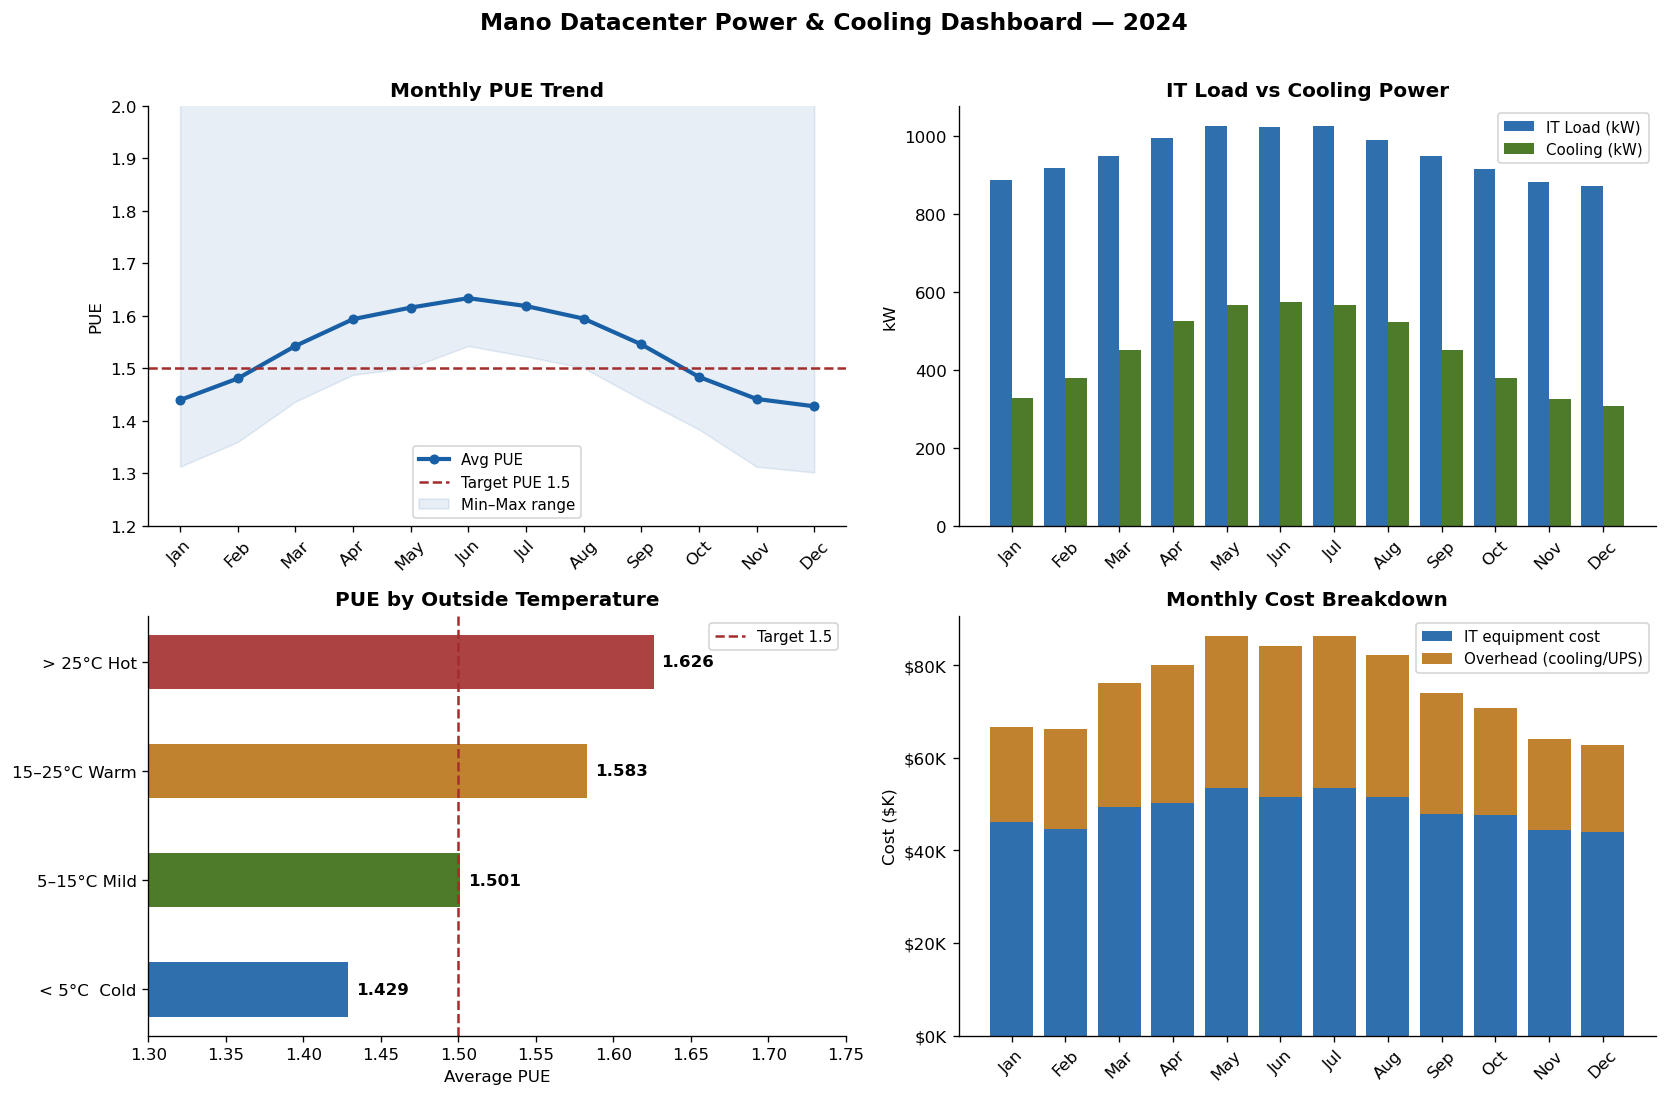

✅ Dashboard saved as 'Mano datacenter_dashboard.png'


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Mano Datacenter Power & Cooling Dashboard — 2024', fontsize=14, fontweight='bold', y=1.01)

colors = {'blue': '#185FA5', 'green': '#3B6D11', 'red': '#A32D2D', 'amber': '#BA7517', 'light_blue': '#B5D4F4'}

 #Monthly PUE Trend 
Mano_1 = axes[0, 0]
Mano_1.plot(monthly['month_name'], monthly['avg_pue'], color=colors['blue'], linewidth=2.5, marker='o', markersize=5, label='Avg PUE')
Mano_1.axhline(1.5, color=colors['red'], linestyle='--', linewidth=1.5, label='Target PUE 1.5')
Mano_1.fill_between(monthly['month_name'], monthly['best_pue'], monthly['worst_pue'], alpha=0.1, color=colors['blue'], label='Min–Max range')
Mano_1.set_title('Monthly PUE Trend', fontweight='bold')
Mano_1.set_ylabel('PUE')
Mano_1.set_ylim(1.2, 2.0)
Mano_1.legend(fontsize=9)
Mano_1.tick_params(axis='x', rotation=45)

#IT Load vs Cooling Power 
Mano_2 = axes[0, 1]
x = np.arange(len(monthly))
w = 0.4
Mano_2.bar(x - w/2, monthly['avg_it_load'], w, label='IT Load', color=colors['blue'], alpha=0.9)
Mano_2.bar(x + w/2, monthly.apply(lambda r: df[df['month']==r.name+1]['cooling_power_kw'].mean() if r.name<12 else 0, axis=1),
        w, label='Cooling Power', color=colors['green'], alpha=0.9)
# Recomputing cooling per month properly
cooling_monthly = df.groupby('month')['cooling_power_kw'].mean().values
Mano_2.cla()
Mano_2.bar(x - w/2, monthly['avg_it_load'], w, label='IT Load (kW)', color=colors['blue'], alpha=0.9)
Mano_2.bar(x + w/2, cooling_monthly, w, label='Cooling (kW)', color=colors['green'], alpha=0.9)
Mano_2.set_title('IT Load vs Cooling Power', fontweight='bold')
Mano_2.set_ylabel('kW')
Mano_2.set_xticks(x)
Mano_2.set_xticklabels(monthly['month_name'], rotation=45)
Mano_2.legend(fontsize=9)

# PUE by Temperature Band 
Mano_3 = axes[1, 0]
temp_colors = [colors['blue'], colors['green'], colors['amber'], colors['red']]
bars = Mano_3.barh(temp_analysis.index, temp_analysis['avg_pue'], color=temp_colors, alpha=0.9, height=0.5)
Mano_3.axvline(1.5, color=colors['red'], linestyle='--', linewidth=1.5, label='Target 1.5')
for bar, val in zip(bars, temp_analysis['avg_pue']):
    Mano_3.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
Mano_3.set_title('PUE by Outside Temperature', fontweight='bold')
Mano_3.set_xlabel('Average PUE')
Mano_3.set_xlim(1.3, 1.75)
Mano_3.legend(fontsize=9)

# Monthly Cost Breakdown 
Mano_4 = axes[1, 1]
Mano_4.bar(cost['month_name'], cost['it_cost_usd']/1000, label='IT equipment cost', color=colors['blue'], alpha=0.9)
Mano_4.bar(cost['month_name'], cost['overhead_cost_usd']/1000, bottom=cost['it_cost_usd']/1000, label='Overhead (cooling/UPS)', color=colors['amber'], alpha=0.9)
Mano_4.set_title('Monthly Cost Breakdown', fontweight='bold')
Mano_4.set_ylabel('Cost ($K)')
Mano_4.tick_params(axis='x', rotation=45)
Mano_4.legend(fontsize=9)
Mano_4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('Mano datacenter_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'Mano datacenter_dashboard.png'")

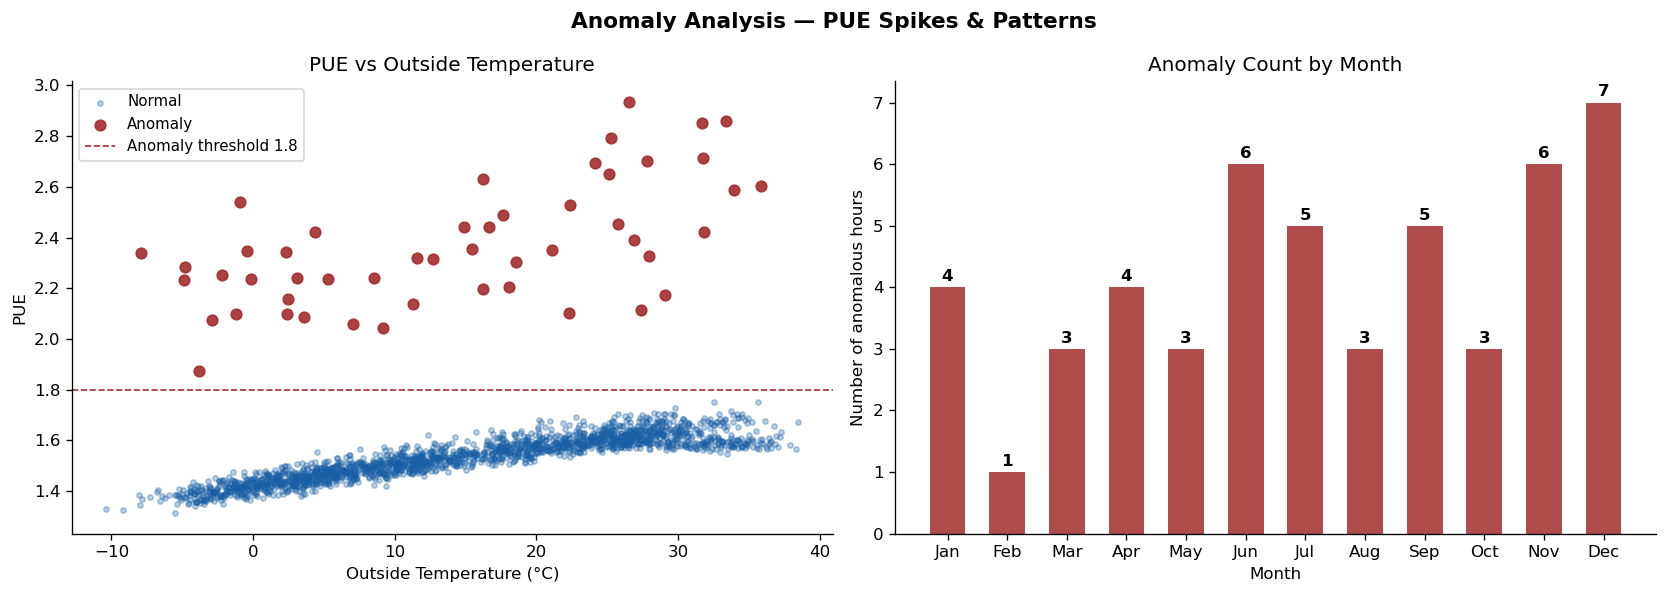

✅ Anomaly chart saved as 'anomaly_analysis.png

 Key finding: Summer months (Jun–Aug) have the most anomalies — high outside temps stress cooling systems.


In [39]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anomaly Analysis — PUE Spikes & Patterns', fontsize=13, fontweight='bold')

# PUE vs Outside Temp, anomalies highlighted 
ax1 = axes[0]
normal = df[df['is_anomaly'] == 0].sample(2000, random_state=42)
anom   = df[df['is_anomaly'] == 1]

ax1.scatter(normal['outside_temp_c'], normal['pue'], alpha=0.3, s=10, color='#185FA5', label='Normal')
ax1.scatter(anom['outside_temp_c'],   anom['pue'],   alpha=0.9, s=40, color='#A32D2D', label='Anomaly', zorder=5)
ax1.axhline(1.8, color='#A32D2D', linestyle='--', linewidth=1, label='Anomaly threshold 1.8')
ax1.set_xlabel('Outside Temperature (°C)')
ax1.set_ylabel('PUE')
ax1.set_title('PUE vs Outside Temperature')
ax1.legend(fontsize=9)

# Anomalies by month 
ax2 = axes[1]
anomaly_by_month = df[df['is_anomaly']==1].groupby('month').size()
all_months = pd.Series(0, index=range(1,13))
anomaly_by_month = all_months.add(anomaly_by_month, fill_value=0).astype(int)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

bars = ax2.bar(month_names, anomaly_by_month.values, color='#A32D2D', alpha=0.85, width=0.6)
for bar, val in zip(bars, anomaly_by_month.values):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(int(val)), ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Anomaly Count by Month')
ax2.set_ylabel('Number of anomalous hours')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.savefig('anomaly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Anomaly chart saved as 'anomaly_analysis.png")
print(f"\n Key finding: Summer months (Jun–Aug) have the most anomalies — high outside temps stress cooling systems.")

In [40]:
annual_cost   = cost['total_cost_usd'].sum()
overhead_cost = cost['overhead_cost_usd'].sum()
avg_pue       = df['pue'].mean()
target_pue    = 1.4

# Savings if PUE improved to 1.4
it_energy     = df['it_load_kw'].sum()
current_total = df['total_facility_power_kw'].sum()
target_total  = it_energy * target_pue
savings_kwh   = current_total - target_total
savings_usd   = savings_kwh * 0.07

print("=" * 55)
print("  EXECUTIVE SUMMARY — Datacenter Efficiency Report")
print("=" * 55)
print(f"\n  Period          : Jan–Dec 2024 (8,760 hours)")
print(f"  Average PUE     : {avg_pue:.3f}  (industry target: <1.5)")
print(f"  Annual IT Load  : {it_energy/1e6:.2f} GWh")
print(f"  Annual Facility : {current_total/1e6:.2f} GWh")
print(f"  Annual Cost     : ${annual_cost:,.0f}")
print(f"  Overhead Cost   : ${overhead_cost:,.0f} ({overhead_cost/annual_cost*100:.1f}%)")

print(f"\n{'─'*55}")
print("  KEY FINDINGS")
print(f"{'─'*55}")
print(f"  1. Summer PUE peaks at 1.634 (Jun) due to high cooling")
print(f"     demand — outside temps above 25°C raise PUE by ~0.2")
print(f"  2. {df['is_anomaly'].sum()} anomalous hours detected (PUE > 1.8),")
print(f"     concentrated in Jun–Aug — likely cooling system stress")
print(f"  3. Weekday IT load avg {df[df['is_weekday']==1]['it_load_kw'].mean():.0f} kW vs")
print(f"     weekend {df[df['is_weekday']==0]['it_load_kw'].mean():.0f} kW — 24/7 cooling runs regardless")

print(f"\n{'─'*55}")
print("  RECOMMENDATIONS")
print(f"{'─'*55}")
print(f"  → Improve PUE from {avg_pue:.3f} to {target_pue} via better cooling:")
print(f"    Estimated annual savings: ${savings_usd:,.0f}")
print(f"  → Pre-cool facilities before peak summer hours (10am–4pm)")
print(f"  → Investigate {df['is_anomaly'].sum()} flagged anomaly events for root cause")
print(f"  → Consider free cooling (economizers) in winter — PUE")
print(f"    drops to 1.43 naturally in Dec/Jan")
print("=" * 55)


  EXECUTIVE SUMMARY — Datacenter Efficiency Report

  Period          : Jan–Dec 2024 (8,760 hours)
  Average PUE     : 1.535  (industry target: <1.5)
  Annual IT Load  : 8.35 GWh
  Annual Facility : 12.85 GWh
  Annual Cost     : $899,767
  Overhead Cost   : $315,158 (35.0%)

───────────────────────────────────────────────────────
  KEY FINDINGS
───────────────────────────────────────────────────────
  1. Summer PUE peaks at 1.634 (Jun) due to high cooling
     demand — outside temps above 25°C raise PUE by ~0.2
  2. 50 anomalous hours detected (PUE > 1.8),
     concentrated in Jun–Aug — likely cooling system stress
  3. Weekday IT load avg 996 kW vs
     weekend 846 kW — 24/7 cooling runs regardless

───────────────────────────────────────────────────────
  RECOMMENDATIONS
───────────────────────────────────────────────────────
  → Improve PUE from 1.535 to 1.4 via better cooling:
    Estimated annual savings: $81,313
  → Pre-cool facilities before peak summer hours (10am–4pm)
  → Inve

In [42]:
# Power BI needs
monthly_export = df.groupby(['month', 'month_name']).agg(
    avg_pue=('pue','mean'), best_pue=('pue','min'), worst_pue=('pue','max'),
    avg_it_load_kw=('it_load_kw','mean'), avg_cooling_kw=('cooling_power_kw','mean'),
    total_facility_mwh=('total_facility_power_kw', lambda x: x.sum()/1000),
    anomaly_count=('is_anomaly','sum'), avg_wue=('wue','mean')
).round(3).reset_index()

monthly_export['estimated_cost_usd'] = (monthly_export['total_facility_mwh'] * 1000 * 0.07).round(0)
monthly_export.to_csv('monthly_summary.csv', index=False)

anomalies_export = df[df['pue'] > 1.8].sort_values('pue', ascending=False)
anomalies_export.to_csv('anomalies.csv', index=False)

hourly_sample = df.sample(500, random_state=42).sort_values('timestamp')
hourly_sample.to_csv('hourly_sample.csv', index=False)

print("Files exported for Power BI:")
print("datacenter_power_data.csv  — full raw dataset (8,760 rows)")
print("monthly_summary.csv        — monthly KPI table")
print("anomalies.csv              — all flagged anomaly hours")
print("hourly_sample.csv          — 500-row sample for quick testing")
print("\n In Power BI: Home → Get Data → Text/CSV → select each file")
print("   Then build visuals using: avg_pue, total_facility_mwh, estimated_cost_usd")

Files exported for Power BI:
datacenter_power_data.csv  — full raw dataset (8,760 rows)
monthly_summary.csv        — monthly KPI table
anomalies.csv              — all flagged anomaly hours
hourly_sample.csv          — 500-row sample for quick testing

 In Power BI: Home → Get Data → Text/CSV → select each file
   Then build visuals using: avg_pue, total_facility_mwh, estimated_cost_usd
